In [51]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [5]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [24]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [12]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

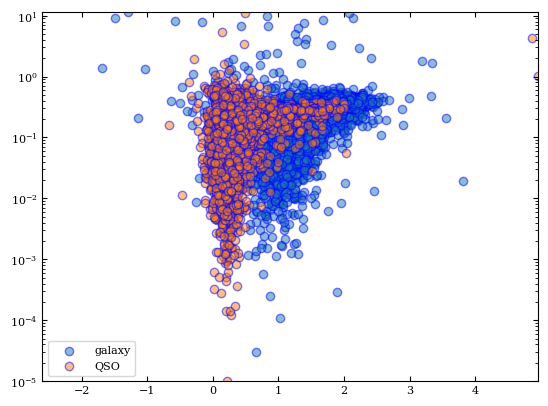

In [68]:
plt.scatter(u_g[cls==0],i_z[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],i_z[cls==1], label='QSO',alpha=0.5)
plt.legend()
plt.yscale('log')
#plt.xscale('log')

In [35]:
from sklearn.naive_bayes import GaussianNB

X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

gnb = GaussianNB()
gnb.fit(X,y)

y_pred = gnb.predict(X)
X.shape

(50000, 5)

In [37]:
from sklearn.naive_bayes import GaussianNB
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve


(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

GAUSSIAN NAIVE BAYES

In [44]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

y_pred = gnb.predict(X_test)
y_pred

array([0., 0., 0., ..., 1., 0., 0.])

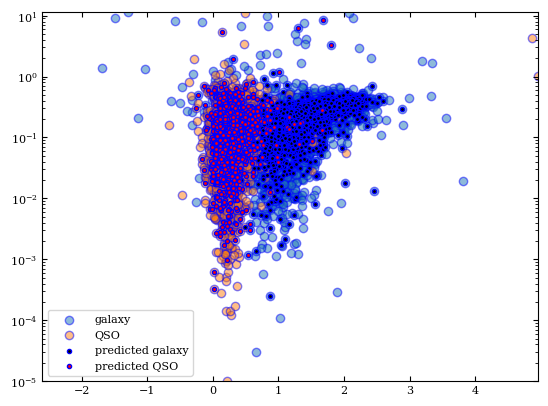

In [81]:
plt.scatter(u_g[cls==0],i_z[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],i_z[cls==1], label='QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred==0],X_test[:,-2][y_pred==0],label='predicted galaxy',marker='.',c='k',edgecolors=None)
plt.scatter(X_test[:,0][y_pred==1],X_test[:,-2][y_pred==1],label='predicted QSO',marker='.',c='r')


plt.legend()
plt.yscale('log')

In [70]:
N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)

y_prob = np.array([])

for nc in Ncolors:
    clf = GaussianNB()
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])
    # Gives the probability for both classes, take just one
    y_prob = np.append(y_prob,clf.predict_proba(X_test[:, :nc])[:,1])

    classifiers.append(clf)
    predictions.append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)


completeness [0.92743764 0.92403628 0.91666667 0.91609977 0.92857143]
contamination [0.06300115 0.1029169  0.10465116 0.11159978 0.05862069]


LINEAR & QUADRATIC DISCRIMINANT ANALYSIS

In [71]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA


lda = LDA()
lda.fit(X_train,y_train)
y_pred_lda = lda.predict(X_test)

qda = QDA()
qda.fit(X_train,y_train)
y_pred_qda = qda.predict(X_test)

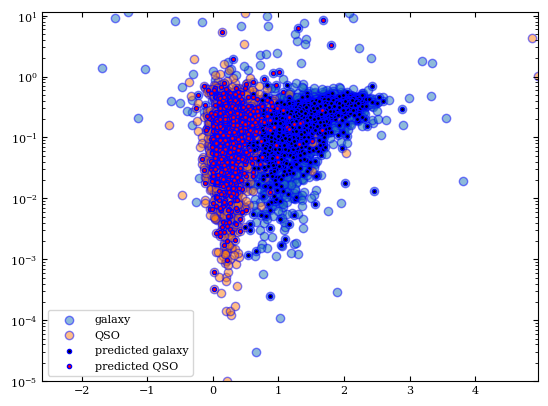

In [80]:
plt.scatter(u_g[cls==0],i_z[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],i_z[cls==1], label='QSO',alpha=0.5)

#plt.scatter(X_test[:,0][y_pred_lda==0],X_test[:,1][y_pred_lda==0],label='predicted galaxy',marker='.',c='k',edgecolors=None)
#plt.scatter(X_test[:,0][y_pred_lda==1],X_test[:,1][y_pred_lda==1],label='predicted QSO',marker='.',c='r')

plt.scatter(X_test[:,0][y_pred_qda==0],X_test[:,-2][y_pred_qda==0],label='predicted galaxy',marker='.',c='k',edgecolors=None)
plt.scatter(X_test[:,0][y_pred_qda==1],X_test[:,-2][y_pred_qda==1],label='predicted QSO',marker='.',c='r')


plt.legend()
plt.yscale('log')

In [76]:
N_tot = len(y)
N_gal = np.sum(y == 0)
N_qso = N_tot - N_gal
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_qso

In [79]:
completenessLDA, contaminationLDA = completeness_contamination(y_pred_lda, y_test)
completenessQDA, contaminationQDA = completeness_contamination(y_pred_qda, y_test)

print("completeness LDA: ", completenessLDA,"\ncompleteness QDA: ", completenessQDA)
print("contamination LDA: ", contaminationLDA,"\ncontamination QDA: ", contaminationQDA)

completeness LDA:  0.8208616780045351 
completeness QDA:  0.941609977324263
contamination LDA:  0.0061770761839396015 
contamination QDA:  0.04595060310166571
